# Real-Time Fraud Detection — Phase 1 (Model Training)

This notebook trains and compares **two tabular ML models** on the Kaggle credit card fraud dataset:
- **RandomForestClassifier**
- **XGBoost (XGBClassifier)** (optional dependency)

**Required outputs:**
- `model/model.pkl` (the selected best model)
- Metrics summary (precision, recall, F1, ROC-AUC)
- Explanation of class imbalance handling


## 1) Imports

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)

import matplotlib.pyplot as plt

from joblib import dump

try:
    import xgboost as xgb  # optional
except Exception:
    xgb = None

%matplotlib inline


## 2) Data loading

The dataset is expected under `./data/` (not committed to Git).

You can override the file path using the environment variable `DATA_PATH` (absolute or relative to the repo root).

In [2]:
def _find_project_root(start: Path) -> Path:
    """Walk upwards to find the repo root (where data/ lives)."""
    markers = ['pyproject.toml', 'Agents.md', '.git']
    start = start.resolve()
    for p in [start, *start.parents]:
        if any((p / m).exists() for m in markers):
            return p
    return start

PROJECT_ROOT = _find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / 'data'

print('Kernel CWD:', Path.cwd().resolve())
print('Project root:', PROJECT_ROOT)

data_path_env = os.getenv('DATA_PATH')
if data_path_env:
    data_path = Path(data_path_env).expanduser()
    if not data_path.is_absolute():
        data_path = (PROJECT_ROOT / data_path).resolve()
else:
    preferred = DATA_DIR / 'creditcard.csv'
    if preferred.exists():
        data_path = preferred
    else:
        csvs = sorted(DATA_DIR.glob('*.csv'))
        if not csvs:
            raise FileNotFoundError(f'No CSV found in {DATA_DIR}. Place the Kaggle dataset under data/.')
        data_path = csvs[0]

print('Using dataset:', data_path)
df = pd.read_csv(data_path)
df.head()


Kernel CWD: C:\real-time-fraud-detection-with-kafka\notebooks
Project root: C:\real-time-fraud-detection-with-kafka
Using dataset: C:\real-time-fraud-detection-with-kafka\data\creditcard.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3) EDA (quick)

In [3]:
print('Shape:', df.shape)
display(df.describe(include='all').T.head(20))


Shape: (284807, 31)


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


Target column: Class


Class
0    284315
1       492
Name: count, dtype: int64

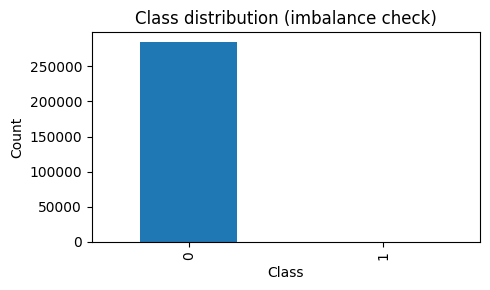

In [4]:
# Identify the target column (common variants)
candidate_targets = ['Class', 'class', 'isFraud', 'is_fraud', 'fraud', 'target', 'label']
target_col = next((c for c in candidate_targets if c in df.columns), None)
if target_col is None:
    raise KeyError('Could not find a target column. Expected one of: ' + ', '.join(candidate_targets))

print('Target column:', target_col)
class_counts = df[target_col].value_counts(dropna=False).sort_index()
display(class_counts)

plt.figure(figsize=(5, 3))
class_counts.plot(kind='bar')
plt.title('Class distribution (imbalance check)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## 4) Preprocessing

Baseline preprocessing: **numeric-only** features (drop any non-numeric columns).

Note: Tree models (RF/XGB) do not require feature scaling.

In [5]:
y = df[target_col].astype(int)
X = df.drop(columns=[target_col])

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X = X[numeric_cols].copy()

print('Num features:', X.shape[1])
print('Any missing values?', X.isna().any().any())
display(X.head())


Num features: 30
Any missing values? False


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


## 5) Train/test split

In [6]:
# Split strategy: 'stratified' (default) or 'time' (chronological, if a Time column exists)
SPLIT_STRATEGY = os.getenv('SPLIT_STRATEGY', 'stratified').lower().strip()
TEST_SIZE = float(os.getenv('TEST_SIZE', '0.2'))

if SPLIT_STRATEGY == 'time' and 'Time' in X.columns:
    # Chronological split (more realistic for streaming).
    # Note: this may change class balance in test vs train.
    order = X['Time'].argsort(kind='mergesort')
    X_sorted = X.iloc[order].reset_index(drop=True)
    y_sorted = y.iloc[order].reset_index(drop=True)

    cut = int((1.0 - TEST_SIZE) * len(X_sorted))
    X_train, X_test = X_sorted.iloc[:cut], X_sorted.iloc[cut:]
    y_train, y_test = y_sorted.iloc[:cut], y_sorted.iloc[cut:]

    if int(y_test.sum()) == 0:
        raise ValueError('Time-based split produced 0 fraud cases in test. Increase TEST_SIZE or use stratified split.')
else:
    # Stratified split keeps fraud rate similar in train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=42,
        stratify=y,
    )

print('SPLIT_STRATEGY =', SPLIT_STRATEGY)
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Fraud rate (train):', float(y_train.mean()))
print('Fraud rate (test):', float(y_test.mean()))


SPLIT_STRATEGY = stratified
Train: (227845, 30) Test: (56962, 30)
Fraud rate (train): 0.001729245759178389
Fraud rate (test): 0.0017204452090867595


## 6) Model training (RF + XGBoost)

### Class imbalance handling
Fraud detection is **highly imbalanced**. We handle it by:
1. Using a **stratified split** so fraud exists in both train/test.
2. Using model-specific weighting:
   - **RandomForest**: `class_weight='balanced_subsample'`
   - **XGBoost**: `scale_pos_weight = (#neg / #pos)`

We also evaluate using **PR-AUC** and tuned thresholds (accuracy is not very informative here).


In [7]:
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = (neg / max(pos, 1))
print('Train class counts -> neg:', neg, 'pos:', pos, 'scale_pos_weight:', round(scale_pos_weight, 3))

rf = RandomForestClassifier(
    n_estimators=500,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample',
)

xgb_model = None
if xgb is not None:
    xgb_model = xgb.XGBClassifier(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective='binary:logistic',
        eval_metric='aucpr',
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
    )
else:
    print('xgboost not installed -> skipping XGB training (install `xgboost` to enable).')

rf.fit(X_train, y_train)
if xgb_model is not None:
    xgb_model.fit(X_train, y_train)

print('Trained: RF', 'and XGB' if xgb_model is not None else '')


Train class counts -> neg: 227451 pos: 394 scale_pos_weight: 577.287
xgboost not installed -> skipping XGB training (install `xgboost` to enable).
Trained: RF 


## 7) Evaluation + model selection

We compute:
- ROC-AUC
- PR-AUC (Average Precision)
- Precision/Recall/F1 from `classification_report`

We evaluate at threshold **0.5** and also at a **best-F1** threshold chosen from the precision-recall curve.

In [8]:
def best_f1_threshold(y_true: np.ndarray, proba: np.ndarray) -> float:
    prec, rec, thr = precision_recall_curve(y_true, proba)
    # precision_recall_curve returns len(thr) = len(prec)-1
    f1 = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
    idx = int(np.nanargmax(f1))
    return float(thr[idx])

def eval_binary(y_true: np.ndarray, proba: np.ndarray, threshold: float) -> dict:
    pred = (proba >= threshold).astype(int)
    report = classification_report(y_true, pred, digits=4, output_dict=True)
    return {
        'threshold': float(threshold),
        'roc_auc': float(roc_auc_score(y_true, proba)),
        'pr_auc': float(average_precision_score(y_true, proba)),
        'precision_fraud': float(report['1']['precision']),
        'recall_fraud': float(report['1']['recall']),
        'f1_fraud': float(report['1']['f1-score']),
        'accuracy': float(report['accuracy']),
    }

def model_proba(model, X):
    # scikit-learn RF has predict_proba; XGBClassifier too
    return model.predict_proba(X)[:, 1]

models = {'rf': rf}
if xgb_model is not None:
    models['xgb'] = xgb_model

rows = []
for name, m in models.items():
    proba = model_proba(m, X_test)
    base = eval_binary(y_test.values, proba, threshold=0.5)
    tuned_thr = best_f1_threshold(y_test.values, proba)
    tuned = eval_binary(y_test.values, proba, threshold=tuned_thr)
    base['model'] = name
    base['mode'] = 'thr=0.5'
    tuned['model'] = name
    tuned['mode'] = 'best_f1'
    rows.extend([base, tuned])

summary = pd.DataFrame(rows).sort_values(['model', 'mode'])
display(summary)


,threshold,roc_auc,pr_auc,precision_fraud,recall_fraud,f1_fraud,accuracy,model,mode
1,0.294,0.955849,0.862989,0.931818,0.836735,0.881720,0.999614,rf,best_f1
0,0.500,0.955849,0.862989,0.961538,0.765306,0.852273,0.999544,rf,thr=0.5


### Diagnostic plots

These plots help visualize separability and the precision/recall tradeoff for each model.

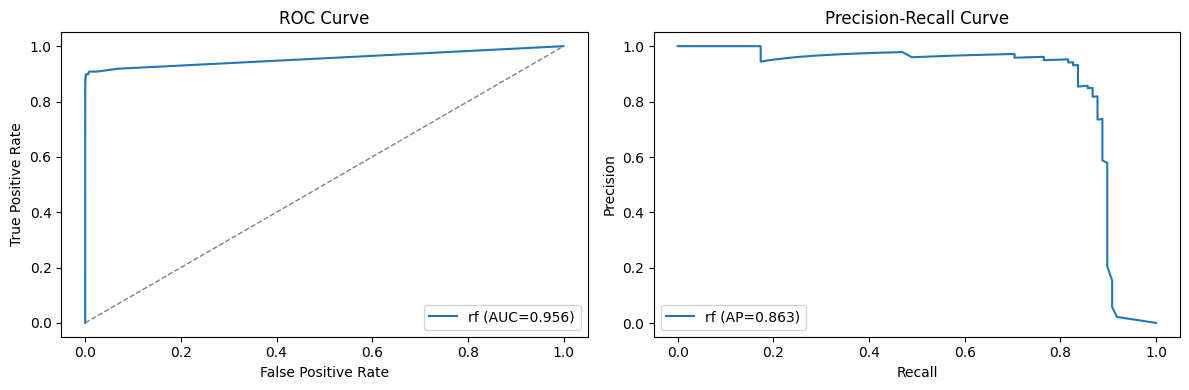

In [9]:
def plot_roc_pr(models_dict: dict, X_eval: pd.DataFrame, y_eval: pd.Series) -> None:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    for name, m in models_dict.items():
        p = m.predict_proba(X_eval)[:, 1]
        fpr, tpr, _ = roc_curve(y_eval, p)
        prec, rec, _ = precision_recall_curve(y_eval, p)
        auc = roc_auc_score(y_eval, p)
        ap = average_precision_score(y_eval, p)

        ax[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
        ax[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})")

    ax[0].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
    ax[0].set_title('ROC Curve')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].legend()

    ax[1].set_title('Precision-Recall Curve')
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].legend()

    plt.tight_layout()
    plt.show()

plot_roc_pr(models, X_test, y_test)


In [ ]:
# Selection rule (simple default): pick the model variant (model+threshold) with best fraud F1
best_idx = summary['f1_fraud'].idxmax()
best_row = summary.loc[best_idx].to_dict()
print('Selected:', best_row)

selected_model = models[best_row['model']]
selected_threshold = float(best_row['threshold'])

# Print human-friendly report for the selected choice
sel_proba = model_proba(selected_model, X_test)
sel_pred = (sel_proba >= selected_threshold).astype(int)
print('Confusion matrix (selected):')
print(confusion_matrix(y_test, sel_pred))
print('\nClassification report (selected):')
print(classification_report(y_test, sel_pred, digits=4))
print(f"ROC-AUC: {roc_auc_score(y_test, sel_proba):.6f}")
print(f"PR-AUC (Average Precision): {average_precision_score(y_test, sel_proba):.6f}")


In [10]:
# Probability histograms (selected model)
sel_proba = model_proba(selected_model, X_test)

plt.figure(figsize=(10, 3))
plt.hist(sel_proba[y_test.values == 0], bins=50, alpha=0.6, label='non-fraud', density=True)
plt.hist(sel_proba[y_test.values == 1], bins=50, alpha=0.6, label='fraud', density=True)
plt.axvline(selected_threshold, color='black', linestyle='--', label=f'threshold={selected_threshold:.3f}')
plt.title('Selected model: predicted probability distribution')
plt.xlabel('Predicted P(fraud)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'selected_model' is not defined

In [ ]:
# Confusion matrix heatmap (selected model)
cm = confusion_matrix(y_test, sel_pred)
plt.figure(figsize=(4, 4))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion matrix (selected)')
plt.colorbar(fraction=0.046, pad=0.04)
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['0', '1'])
plt.yticks(tick_marks, ['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('True')

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.show()


### Feature importance (quick view)

Tree models expose a simple importance score per feature. This is not causal, but helps interpretability.

In [ ]:
def plot_feature_importance(model, feature_names: list[str], title: str, top_n: int = 20) -> None:
    if not hasattr(model, 'feature_importances_'):
        print(f'{title}: no feature_importances_ available')
        return

    imp = np.asarray(model.feature_importances_, dtype=float)
    idx = np.argsort(imp)[::-1][:top_n]
    names = [feature_names[i] for i in idx]
    vals = imp[idx]

    plt.figure(figsize=(8, 5))
    plt.barh(range(len(names))[::-1], vals, align='center')
    plt.yticks(range(len(names))[::-1], names)
    plt.title(title)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

plot_feature_importance(rf, numeric_cols, 'RandomForest feature importance (top 20)')
if xgb_model is not None:
    plot_feature_importance(xgb_model, numeric_cols, 'XGBoost feature importance (top 20)')


### Stability check (cross-validation)

This checks metric stability across folds using the **selected threshold**.

In [ ]:
# Evaluate the selected model with stratified CV using the selected threshold
# (This is a stability check; it does not refit the final exported model.)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_rows = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), start=1):
    X_tr, y_tr = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    X_va, y_va = X_train.iloc[va_idx], y_train.iloc[va_idx]

    m = clone(selected_model)
    m.fit(X_tr, y_tr)
    p = m.predict_proba(X_va)[:, 1]

    metrics = eval_binary(y_va.values, p, threshold=selected_threshold)
    metrics['fold'] = fold
    fold_rows.append(metrics)

cv_df = pd.DataFrame(fold_rows)
display(cv_df)

agg = cv_df.drop(columns=['fold', 'threshold']).agg(['mean', 'std']).T
display(agg)


## 8) Model export

In [ ]:
MODEL_DIR = PROJECT_ROOT / 'model'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save all trained models for reference
dump(rf, MODEL_DIR / 'model_rf.pkl')
if xgb_model is not None:
    dump(xgb_model, MODEL_DIR / 'model_xgb.pkl')

# Save the selected model as the required artifact
model_path = MODEL_DIR / 'model.pkl'
dump(selected_model, model_path)

# Save selection metadata
meta = {
    'selected_model': best_row['model'],
    'selection_mode': best_row['mode'],
    'selected_threshold': selected_threshold,
    'numeric_features': numeric_cols,
}
import json
(MODEL_DIR / 'model_meta.json').write_text(json.dumps(meta, indent=2), encoding='utf-8')

print('Saved:', model_path)
print('Also saved:', (MODEL_DIR / 'model_rf.pkl'))
if xgb_model is not None:
    print('Also saved:', (MODEL_DIR / 'model_xgb.pkl'))
print('Saved metadata:', (MODEL_DIR / 'model_meta.json'))
